# Estimacion de Reservas IBNR con Tres Metodos

Este cuaderno desarrolla la estimacion de reservas por **siniestros incurridos pero no reportados**
(IBNR, *Incurred But Not Reported*) aplicando tres metodos clasicos sobre un triangulo de desarrollo
de siniestros acumulados:

1. **Chain Ladder** -- proyeccion determinista basada en factores de desarrollo.
2. **Bornhuetter-Ferguson** -- combina experiencia observada con un loss ratio a priori.
3. **Bootstrap** -- simulacion Monte Carlo que genera la distribucion completa de reservas.

Al final se comparan los resultados de los tres enfoques y se discuten las fortalezas y
debilidades de cada uno.

In [1]:
import sys
sys.path.insert(0, "../src")

from decimal import Decimal
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Estilo de graficas
plt.rcParams.update({
    "figure.figsize": (10, 5),
    "axes.grid": True,
    "grid.alpha": 0.3,
})

print("Importaciones exitosas.")

Importaciones exitosas.


## Paso 1: Construir triangulo de desarrollo

Se construye un triangulo **acumulado** de 7 anos de origen (2017--2023) por 7 periodos de
desarrollo. Las cifras representan siniestros acumulados pagados en millones de pesos.

La estructura triangular refleja que los anos mas recientes tienen menos periodos
de desarrollo observados.

In [2]:
# Triangulo acumulado de siniestros (cifras en millones MXN)
# Filas = anos de origen, columnas = periodos de desarrollo
data = [
    [1_200, 2_300, 3_000, 3_400, 3_600, 3_700, 3_800],
    [1_350, 2_550, 3_350, 3_800, 4_000, 4_100, None],
    [1_400, 2_650, 3_480, 3_950, 4_150, None, None],
    [1_500, 2_850, 3_700, 4_200, None, None, None],
    [1_550, 2_900, 3_780, None, None, None, None],
    [1_600, 3_000, None, None, None, None, None],
    [1_700, None, None, None, None, None, None],
]

triangulo = pd.DataFrame(
    data,
    index=[2017, 2018, 2019, 2020, 2021, 2022, 2023],
    columns=list(range(7)),
    dtype=float,
)

print("Triangulo de desarrollo acumulado (millones MXN):")
print()
print(triangulo.to_string(na_rep="---", float_format="{:,.0f}".format))

Triangulo de desarrollo acumulado (millones MXN):

         0     1     2     3     4     5     6
2017 1,200 2,300 3,000 3,400 3,600 3,700 3,800
2018 1,350 2,550 3,350 3,800 4,000 4,100   ---
2019 1,400 2,650 3,480 3,950 4,150   ---   ---
2020 1,500 2,850 3,700 4,200   ---   ---   ---
2021 1,550 2,900 3,780   ---   ---   ---   ---
2022 1,600 3,000   ---   ---   ---   ---   ---
2023 1,700   ---   ---   ---   ---   ---   ---


## Paso 2: Chain Ladder

El metodo **Chain Ladder** calcula factores de desarrollo *age-to-age* a partir del
triangulo historico y los utiliza para proyectar las celdas faltantes.

1. Se obtienen los factores individuales $f_{i,j} = C_{i,j+1} / C_{i,j}$.
2. Se promedian (promedio simple) para obtener el factor seleccionado por periodo.
3. Se completa el triangulo y se calculan los *ultimates* y las reservas.

In [3]:
from suite_actuarial.reservas.chain_ladder import ChainLadder
from suite_actuarial.core.models.reservas import (
    ConfiguracionChainLadder,
    MetodoPromedio,
)

config_cl = ConfiguracionChainLadder(
    metodo_promedio=MetodoPromedio.SIMPLE,
    calcular_tail_factor=False,
)

cl = ChainLadder(config_cl)
resultado_cl = cl.calcular(triangulo)

# Factores de desarrollo
print("Factores de desarrollo seleccionados (promedio simple):")
for i, f in enumerate(resultado_cl.factores_desarrollo):
    print(f"  Periodo {i} -> {i+1}: {float(f):.6f}")

print(f"\nFactor de desarrollo acumulado al ultimate: "
      f"{float(np.prod([float(f) for f in resultado_cl.factores_desarrollo])):.6f}")

Factores de desarrollo seleccionados (promedio simple):
  Periodo 0 -> 1: 1.890730
  Periodo 1 -> 2: 1.306595
  Periodo 2 -> 3: 1.134464
  Periodo 3 -> 4: 1.054029
  Periodo 4 -> 5: 1.026389
  Periodo 5 -> 6: 1.027027

Factor de desarrollo acumulado al ultimate: 3.113921


In [4]:
# Triangulo completo y resultados
print("Triangulo completo (proyectado):")
tc_completo = cl.obtener_triangulo_completo()
print(tc_completo.to_string(float_format="{:,.0f}".format))
print()

# Ultimates y reservas por ano
print(f"{'Ano':>6}  {'Pagado':>12}  {'Ultimate':>12}  {'Reserva':>12}")
print("-" * 50)
for anio in sorted(resultado_cl.ultimates_por_anio.keys()):
    ult = resultado_cl.ultimates_por_anio[anio]
    res = resultado_cl.reservas_por_anio[anio]
    pag = ult - res
    print(f"{anio:6d}  {float(pag):>12,.0f}  {float(ult):>12,.0f}  {float(res):>12,.0f}")

print(f"\nReserva total Chain Ladder: ${float(resultado_cl.reserva_total):,.0f}")

Triangulo completo (proyectado):
         0     1     2     3     4     5     6
2017 1,200 2,300 3,000 3,400 3,600 3,700 3,800
2018 1,350 2,550 3,350 3,800 4,000 4,100 4,211
2019 1,400 2,650 3,480 3,950 4,150 4,260 4,375
2020 1,500 2,850 3,700 4,200 4,427 4,544 4,667
2021 1,550 2,900 3,780 4,288 4,520 4,639 4,765
2022 1,600 3,000 3,920 4,447 4,687 4,811 4,941
2023 1,700 3,214 4,200 4,764 5,022 5,154 5,294

   Ano        Pagado      Ultimate       Reserva
--------------------------------------------------
  2017         3,800         3,800             0
  2018         4,100         4,211           111
  2019         4,150         4,375           225
  2020         4,200         4,667           467
  2021         3,780         4,765           985
  2022         3,000         4,941         1,941
  2023         1,700         5,294         3,594

Reserva total Chain Ladder: $7,321


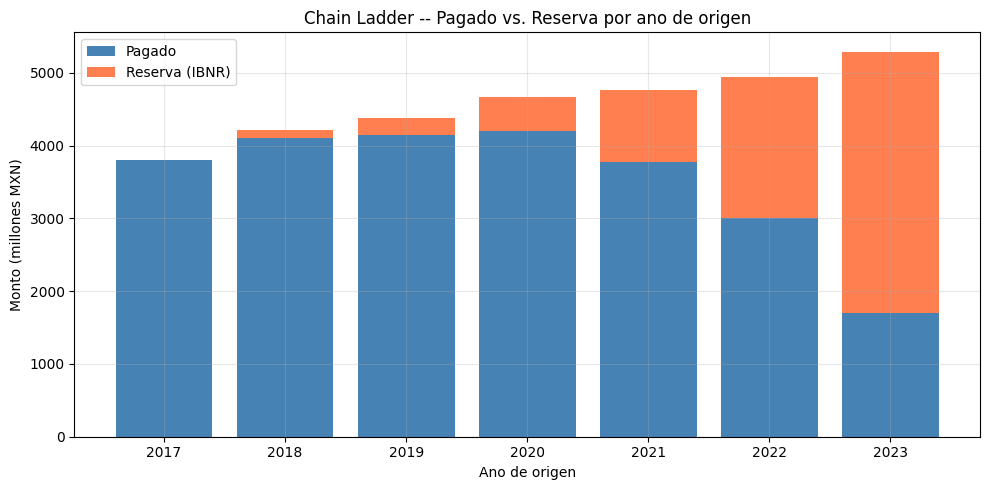

In [5]:
# Grafica: reservas por ano de origen (stacked bar chart)
anios_cl = sorted(resultado_cl.reservas_por_anio.keys())
pagados_cl = [float(resultado_cl.ultimates_por_anio[a] - resultado_cl.reservas_por_anio[a]) for a in anios_cl]
reservas_cl = [float(resultado_cl.reservas_por_anio[a]) for a in anios_cl]

fig, ax = plt.subplots()
ax.bar(anios_cl, pagados_cl, label="Pagado", color="steelblue")
ax.bar(anios_cl, reservas_cl, bottom=pagados_cl, label="Reserva (IBNR)", color="coral")
ax.set_xlabel("Ano de origen")
ax.set_ylabel("Monto (millones MXN)")
ax.set_title("Chain Ladder -- Pagado vs. Reserva por ano de origen")
ax.legend()
plt.tight_layout()
plt.show()

## Paso 3: Bornhuetter-Ferguson

El metodo **Bornhuetter-Ferguson** (B-F) estabiliza la proyeccion de anos recientes
incorporando un *loss ratio a priori* (expectativa del negocio).

La formula es:
$$\text{Ultimate}_{BF} = \text{Pagado} + \text{Prima} \times LR_{apriori} \times (1 - \% \text{Reportado})$$

Se utiliza un loss ratio a priori del **70%** y primas ganadas por ano.

In [6]:
from suite_actuarial.reservas.bornhuetter_ferguson import BornhuetterFerguson
from suite_actuarial.core.models.reservas import ConfiguracionBornhuetterFerguson

config_bf = ConfiguracionBornhuetterFerguson(
    loss_ratio_apriori=Decimal("0.70"),
    metodo_promedio=MetodoPromedio.SIMPLE,
)

# Primas ganadas por ano de origen (millones MXN)
primas_por_anio = {
    2017: Decimal("5000"),
    2018: Decimal("5200"),
    2019: Decimal("5500"),
    2020: Decimal("5800"),
    2021: Decimal("6000"),
    2022: Decimal("6200"),
    2023: Decimal("6500"),
}

bf = BornhuetterFerguson(config_bf)
resultado_bf = bf.calcular(triangulo, primas_por_anio)

# Resultados
print(f"{'Ano':>6}  {'Ultimate CL':>14}  {'Ultimate BF':>14}  {'Reserva BF':>14}")
print("-" * 56)
for anio in sorted(resultado_bf.ultimates_por_anio.keys()):
    ult_cl = resultado_cl.ultimates_por_anio[anio]
    ult_bf = resultado_bf.ultimates_por_anio[anio]
    res_bf = resultado_bf.reservas_por_anio[anio]
    print(f"{anio:6d}  {float(ult_cl):>14,.0f}  {float(ult_bf):>14,.0f}  {float(res_bf):>14,.0f}")

print(f"\nReserva total Bornhuetter-Ferguson: ${float(resultado_bf.reserva_total):,.0f}")

   Ano     Ultimate CL     Ultimate BF      Reserva BF
--------------------------------------------------------
  2017           3,800           3,800               0
  2018           4,211           4,196              96
  2019           4,375           4,348             198
  2020           4,667           4,606             406
  2021           4,765           4,648             868
  2022           4,941           4,705           1,705
  2023           5,294           4,789           3,089

Reserva total Bornhuetter-Ferguson: $6,361


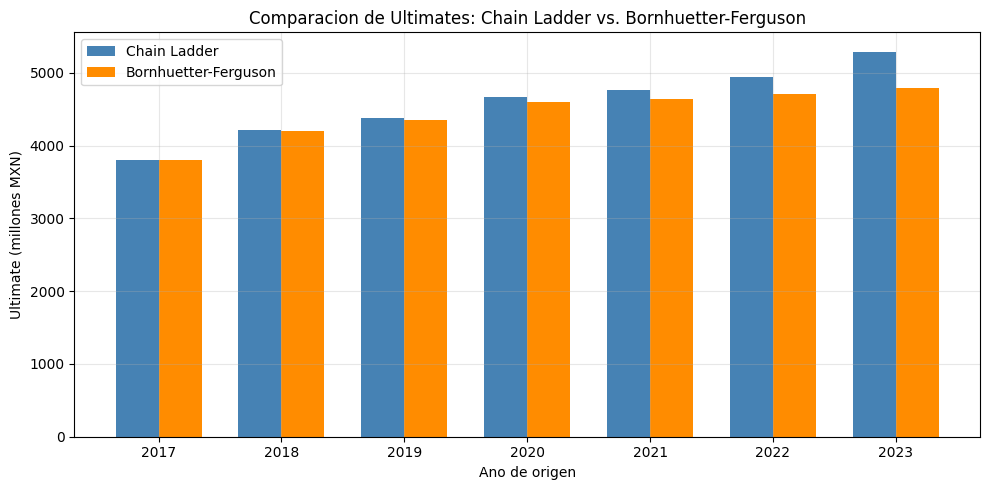

In [7]:
# Grafica comparativa CL vs BF
anios_sorted = sorted(resultado_cl.ultimates_por_anio.keys())
ult_cl_vals = [float(resultado_cl.ultimates_por_anio[a]) for a in anios_sorted]
ult_bf_vals = [float(resultado_bf.ultimates_por_anio[a]) for a in anios_sorted]

fig, ax = plt.subplots()
x = np.arange(len(anios_sorted))
width = 0.35
ax.bar(x - width/2, ult_cl_vals, width, label="Chain Ladder", color="steelblue")
ax.bar(x + width/2, ult_bf_vals, width, label="Bornhuetter-Ferguson", color="darkorange")
ax.set_xlabel("Ano de origen")
ax.set_ylabel("Ultimate (millones MXN)")
ax.set_title("Comparacion de Ultimates: Chain Ladder vs. Bornhuetter-Ferguson")
ax.set_xticks(x)
ax.set_xticklabels(anios_sorted)
ax.legend()
plt.tight_layout()
plt.show()

## Paso 4: Bootstrap (intervalos de confianza)

El metodo **Bootstrap** genera la **distribucion completa** de posibles valores de reserva
mediante simulacion Monte Carlo:

1. Ejecuta Chain Ladder como modelo base.
2. Calcula residuales de Pearson.
3. Re-muestrea residuales para generar triangulos sinteticos.
4. Ejecuta Chain Ladder en cada triangulo sintetico.
5. Obtiene percentiles (P50, P75, P90, P95, P99).

Esto permite cuantificar la **incertidumbre** y calcular medidas como VaR y TVaR.

In [8]:
from suite_actuarial.reservas.bootstrap import Bootstrap
from suite_actuarial.core.models.reservas import ConfiguracionBootstrap

config_bs = ConfiguracionBootstrap(
    num_simulaciones=1000,
    seed=42,
    percentiles=[50, 75, 90, 95, 99],
)

bs = Bootstrap(config_bs)
resultado_bs = bs.calcular(triangulo)

# Tabla de percentiles
print("Distribucion de reservas totales (Bootstrap, 1,000 simulaciones):")
print()
print(f"{'Percentil':>12}  {'Reserva Total':>16}")
print("-" * 32)
for p, val in sorted(resultado_bs.percentiles.items()):
    print(f"{'P' + str(p):>12}  ${float(val):>16,.0f}")

print(f"\nMedia:              ${float(resultado_bs.detalles['media']):>16,.0f}")
print(f"Desv. estandar:     ${float(resultado_bs.detalles['desviacion_estandar']):>16,.0f}")
print(f"Coef. de variacion: {float(resultado_bs.detalles['coeficiente_variacion']):>16.4f}")

Distribucion de reservas totales (Bootstrap, 1,000 simulaciones):

   Percentil     Reserva Total
--------------------------------
         P50  $           7,376
         P75  $           7,587
         P90  $           7,792
         P95  $           7,921
         P99  $          95,483

Media:              $           9,047
Desv. estandar:     $          12,034
Coef. de variacion:           1.3302


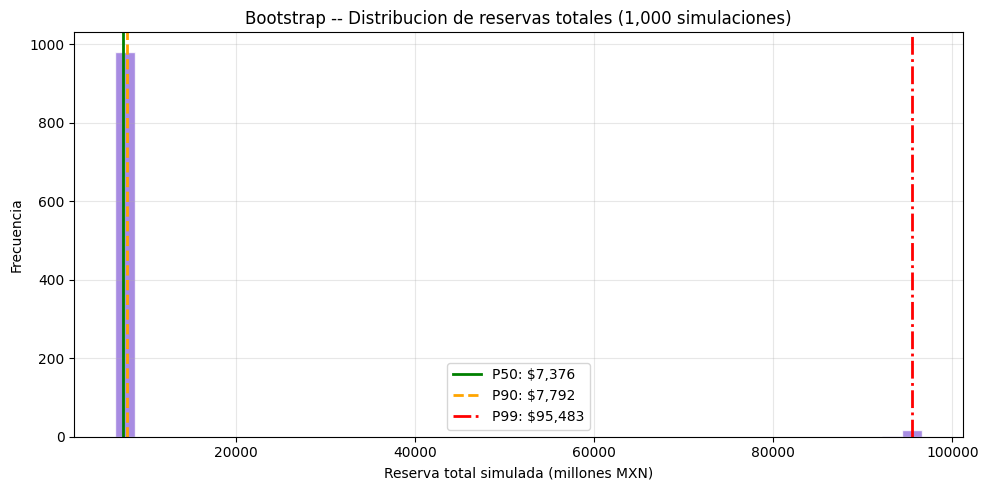

In [9]:
# Histograma de reservas simuladas
sim_vals = [float(s) for s in bs.obtener_distribucion()]

fig, ax = plt.subplots()
ax.hist(sim_vals, bins=40, color="mediumpurple", edgecolor="white", alpha=0.8)

# Lineas verticales en percentiles clave
for p, color, ls in [(50, "green", "-"), (90, "orange", "--"), (99, "red", "-.")]:
    val = float(resultado_bs.percentiles[p])
    ax.axvline(val, color=color, linestyle=ls, linewidth=2, label=f"P{p}: ${val:,.0f}")

ax.set_xlabel("Reserva total simulada (millones MXN)")
ax.set_ylabel("Frecuencia")
ax.set_title("Bootstrap -- Distribucion de reservas totales (1,000 simulaciones)")
ax.legend()
plt.tight_layout()
plt.show()

## Paso 5: Comparacion de los tres metodos

Se presenta una tabla consolidada con las estimaciones de reserva total de cada metodo.
Para Bootstrap se usa el percentil 75 (P75), que es un nivel de confianza conservador
frecuentemente utilizado en la practica regulatoria mexicana.

In [10]:
# Tabla comparativa
reserva_cl = float(resultado_cl.reserva_total)
reserva_bf = float(resultado_bf.reserva_total)
reserva_bs_p75 = float(resultado_bs.percentiles[75])

df_comparacion = pd.DataFrame({
    "Metodo": ["Chain Ladder", "Bornhuetter-Ferguson", "Bootstrap (P75)"],
    "Reserva Total": [reserva_cl, reserva_bf, reserva_bs_p75],
})
df_comparacion["Diferencia vs CL"] = df_comparacion["Reserva Total"] - reserva_cl
df_comparacion["Diferencia %"] = (df_comparacion["Diferencia vs CL"] / reserva_cl * 100)

print("Comparacion de reservas totales estimadas:")
print()
print(df_comparacion.to_string(index=False, float_format="{:,.0f}".format))

Comparacion de reservas totales estimadas:

              Metodo  Reserva Total  Diferencia vs CL  Diferencia %
        Chain Ladder          7,321                 0             0
Bornhuetter-Ferguson          6,361              -960           -13
     Bootstrap (P75)          7,587               266             4


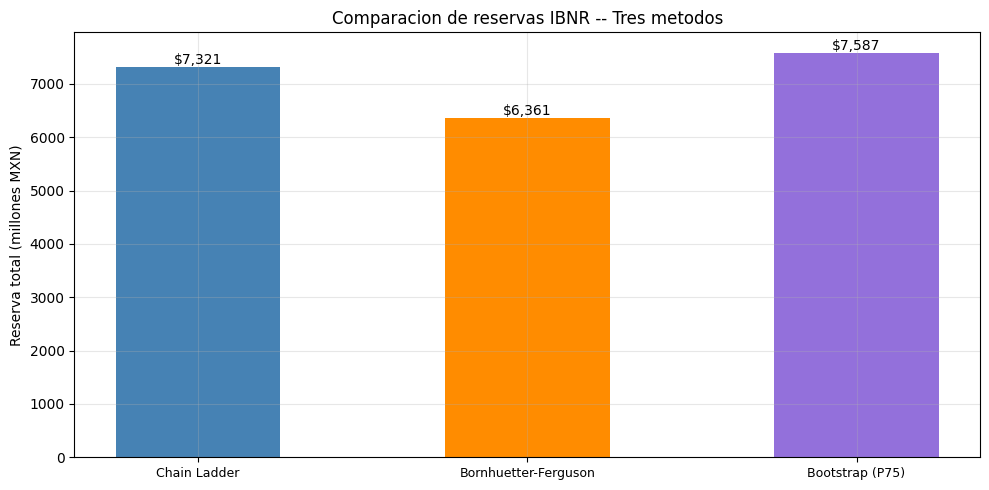

In [11]:
# Grafica de barras comparativa
fig, ax = plt.subplots()
metodos = df_comparacion["Metodo"]
valores = df_comparacion["Reserva Total"]
colores = ["steelblue", "darkorange", "mediumpurple"]

bars = ax.bar(range(len(metodos)), valores, color=colores, width=0.5)
ax.set_xticks(range(len(metodos)))
ax.set_xticklabels(metodos, fontsize=9)
ax.set_ylabel("Reserva total (millones MXN)")
ax.set_title("Comparacion de reservas IBNR -- Tres metodos")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f"${height:,.0f}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.show()

## Conclusiones

### Cuando usar cada metodo

| Metodo | Fortalezas | Debilidades | Uso recomendado |
|--------|------------|-------------|------------------|
| **Chain Ladder** | Sencillo, transparente, estandar de la industria | Sensible a anomalias en anos recientes | Ramos estables con suficiente historia |
| **Bornhuetter-Ferguson** | Estable para anos recientes, incorpora juicio actuarial | Depende del loss ratio a priori elegido | Anos con poco desarrollo o ramos nuevos |
| **Bootstrap** | Distribucion completa, cuantifica incertidumbre, permite VaR/TVaR | Mayor complejidad computacional | Capital economico, Solvencia II, reportes regulatorios |

### Observaciones clave

1. **Chain Ladder** es el punto de partida natural. Sus factores de desarrollo revelan
   el patron historico de reporte y pago de siniestros.

2. **Bornhuetter-Ferguson** es preferible cuando los anos mas recientes muestran
   poca informacion y se dispone de una estimacion confiable del loss ratio.

3. **Bootstrap** es indispensable para la gestion de riesgos moderna: al generar la
   distribucion completa, permite calcular intervalos de confianza, VaR y TVaR,
   elementos centrales en los marcos de Solvencia II y el RCS de la CNSF.

4. En la practica, el actuario debe comparar los tres metodos y aplicar juicio
   profesional para seleccionar la mejor estimacion (*best estimate*) segun las
   caracteristicas del ramo y la calidad de los datos.